In [1]:
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
from tqdm import tqdm


In [2]:
sys.path.insert(0, "/lustre/lrspec/users/4301/ABC-SN/code")
from data_degrading import degrade_spectrum
import abcsn_training
import abcsn_config

sys.path.insert(0, "/lustre/lrspec/users/4301/Milligan_project")
from process_data import *


sys.path.insert(0, "/lustre/lrspec/users/4301/snidpy/sourcepy")
from apodize import *
from logwave import Logwave as lw
from logwave import log_rebin

2026-04-22 22:54:25.113635: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-22 22:54:25.723255: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-22 22:54:30.169876: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [3]:
abcsn = keras.models.load_model("/lustre/lrspec/users/4301/ABC-SN/abcsn/ABCSN.keras", compile=False)

2026-04-22 22:54:34.168983: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [4]:
# used:
# abcsn_config.SN_Stypes_int_to_str replaced with ABC_subtype_id_to_str
# to make the dictionary corresponding to the labels used above
# may just want to change the above to use the same strings as int_to_str function
ABC_subtype_id_to_str = {
    0: "Ia-norm",
    1: "Ia-91T",
    2: "Ia-91bg",
    3: "Iax",
    4: "Ib-norm",
    5: "Ibn",
    6: "IIb",
    7: "Ic-norm",
    8: "Ic-broad",
    9: "IIP",
}

ABC_ID_dict ={"Ia": 0,
          "Iap": 0,
          "Ic": 7,
          "Ib": 4,
          "II": 9, # IIP = type 2 plateau = normal
          "IIb": 6,
          "IIn": 9,
          "SL": None,
          "TDE": None,
          "CaRT": None
          }

Mill_ID_dict ={"Ia": 0,
          "Iap": 0,
          "Ic": 1,
          "Ib": 1,
          "II": 2, # IIP = type 2 plateau = normal
          "IIb": 1,
          "IIn": 2,
          "SL": 3,
          "TDE": 4,
          "CaRT": 4
          }

# five types recorded in Milligan et al.
Mill_types_to_int = {0: "Ia",
                     1: "Ib & Ic",
                     2: "II",
                     3: "SLSN",
                     4: "Non-SN",
                     5: "other"
                     }

# convert ABC types to Mill categories
ABC_to_Mill ={0:0,   # Ia-norm -> Ia
              1:0,   # Ia-91T -> Ia
              2:0,   # Ia-91bg -> Ia
              3:0,   # Iax -> Ia
              4:1,   # Ib-norm -> Ib & Ic
              5:1,   # Ibn -> Ib & Ic
              6:1,   # IIb -> Ib & Ic
              7:1,  # Ic-norm -> Ib & Ic
              8:1,  # Ic-broad -> Ib & Ic
              9:2,  # IIP -> II
            }


In [38]:
folder_list = ["kinney_sample1", "kinney_sample2", "kinney_sample3", "kinney_sample4", "kinney_sample5",
               "kinney_sample6", "kinney_sample7", "kinney_sample8", "kinney_sample9",
               "kinney_sample10", "kinney_sample11", "kinney_sample12", "kinney_sample13",
               "kinney_sample14"]

columns = ['filename', 'host', 'sn_type', 'redshift', 'SN_mag', 'host_mag',
           'ABC_ID', 'Mill_ID']
num_wvl = 139
len_data = 458
X_all = np.zeros((0, 1, num_wvl))
df = pd.DataFrame(columns = columns)
    
for folder in tqdm(folder_list):
    filenames = glob.glob("/lustre/lrspec/users/4301/Milligan_ABC-SN/data/"+ folder +"/*")
    file_info = [name.split("/")[-1] for name in filenames]
    temp_df = pd.DataFrame(file_info, columns=["filename"])
    temp_df[["host", "sn_type", "redshift", "SN_mag", "host_mag"]] = [get_filename_info(info) for info in file_info]
    temp_df[ "host_mag"] = temp_df[ "host_mag"].astype(float)
    temp_df[ "redshift"] = temp_df[ "redshift"].astype(float)
    temp_df[ "SN_mag"] = temp_df[ "SN_mag"].astype(float)

    # only need the data with low redshift
    # low_redshift_index = temp_df.redshift < 0.05
    # temp_df = temp_df[low_redshift_index].reset_index()
    
    

    # set up to extract the X values 
    num_wvl = 139
    dat_size = len(temp_df)
    plots = False
    
    X_temp = np.zeros((dat_size, 1, num_wvl))
    
    for i in range(dat_size):
        file = "/lustre/lrspec/users/4301/Milligan_ABC-SN/data/"+ folder +"/" + temp_df.filename[i]
        wvl, X = process_files(file, 4500, 7000, plot_spectra = plots, verbose=False)
        X_temp[i] = X
        
        
        # dont save wvl as all are the same
    
    X_all = np.append(X_all, X_temp, axis=0)
    df = pd.concat([df, temp_df], ignore_index=True)
    
    


  0%|          | 0/14 [00:00<?, ?it/s]/tmp/ipykernel_33400/2681645955.py:44: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, temp_df], ignore_index=True)
100%|██████████| 14/14 [36:46<00:00, 157.58s/it]


/tmp/ipykernel_33400/1208245475.py:24: RuntimeWarning: invalid value encountered in divide
  ax.plot(wvl, X_temp/dat_size , alpha = 1, color = "r", label="Average")


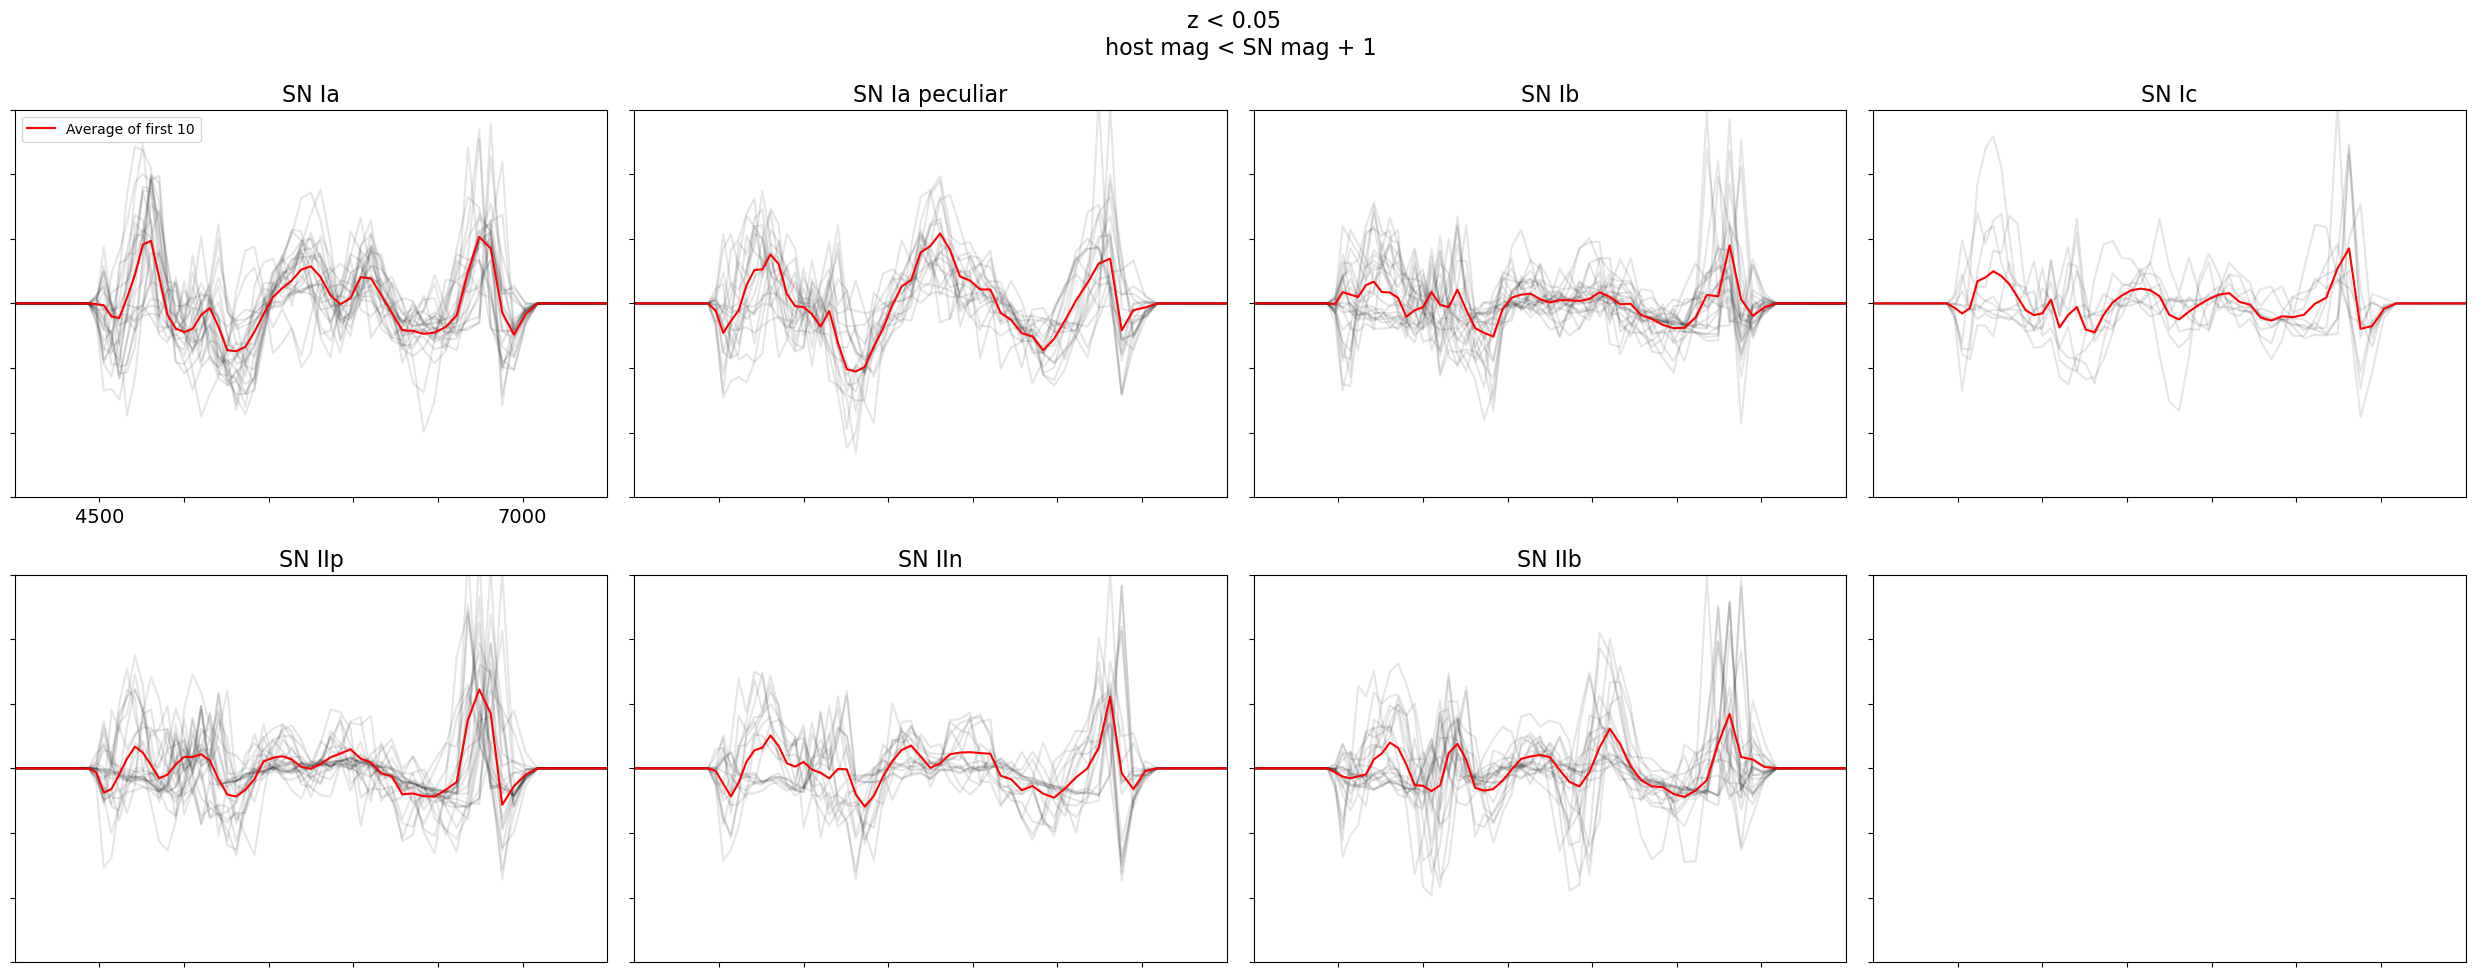

In [33]:
types = ['Ia', 'Iap', 'Ib',   'Ic', 'II', 'IIn', 'IIb', ""]
types_titles = ['SN Ia', 'SN Ia peculiar', 'SN Ib',   'SN Ic', 'SN IIp', 'SN IIn', 'SN IIb', '']
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(25, 10)) # Adjust figsize as needed
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration
brighter_SN_index = df.host_mag < df.SN_mag + 1
small_z_index = df.redshift < 0.05
close_bright_df = df[brighter_SN_index & small_z_index] #df[brighter_SN_index & small_z_index]


for j, sn_type in enumerate(types):
    ax = axes[j]
    temp_df = close_bright_df[close_bright_df.sn_type == sn_type]
    
    dat_size = len(temp_df)
    X_temp = np.zeros((num_wvl, ))

    for n, i in enumerate(temp_df.index.values):
        if n < 10:
            X_temp += X_all[i][0]
        if n < 25:
            ax.plot(wvl, X_all[i][0], alpha = 0.1, color = "k")

    if dat_size < 10:
        ax.plot(wvl, X_temp/dat_size , alpha = 1, color = "r", label="Average")
    else:
        ax.plot(wvl, X_temp/10 , alpha = 1, color = "r", label="Average of first 10")
    ax.set_title(f"{types_titles[j]}", fontsize = 16)
    ax.set_ylim(-3, 3)
    ax.set_xlim(4000,7500)
    ax.set_xticks([4500, 5000, 5500, 6000, 6500, 7000])
    ax.set_xticklabels(['', '', '', '', '', ''])
    ax.set_yticklabels([])
    if j == 0:
        ax.legend()
        ax.set_xticks([4500, 5000, 5500, 6000, 6500, 7000])
        ax.set_xticklabels([4500, '', '', '', '', 7000], fontsize = 14)

fig.suptitle("z < 0.05 \n host mag < SN mag + 1", fontsize =16)
plt.tight_layout(pad = 1.6) # Adjust layout to prevent overlapping titles/labels

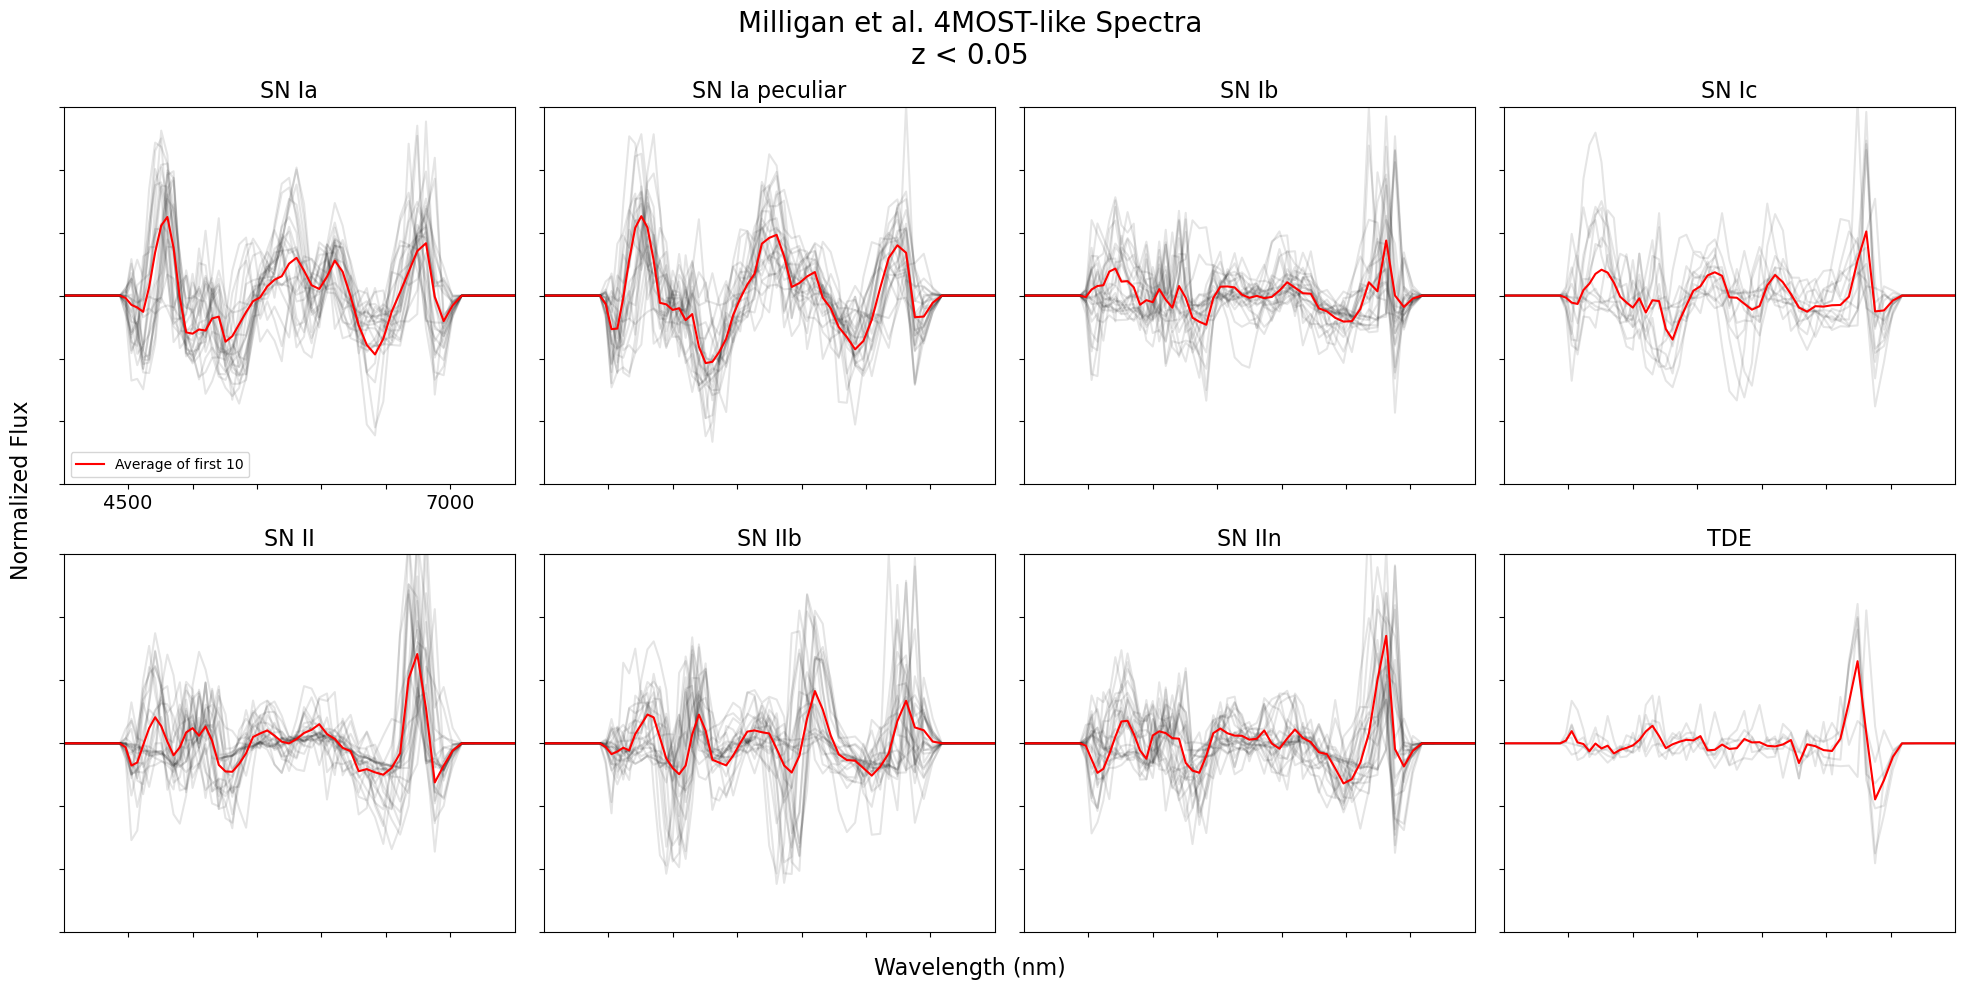

In [79]:
types = ['Ia', 'Iap', 'Ib',   'Ic', 'II', 'IIb', 'IIn', "TDE"]
types_titles = ['SN Ia', 'SN Ia peculiar', 'SN Ib',   'SN Ic', 'SN II', 'SN IIb', 'SN IIn', 'TDE']
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10)) # Adjust figsize as needed
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration
brighter_SN_index = df.host_mag < df.SN_mag + 1
small_z_index = df.redshift < 0.05
close_bright_df = df[small_z_index] #df[brighter_SN_index & small_z_index]


for j, sn_type in enumerate(types):
    ax = axes[j]
    temp_df = close_bright_df[close_bright_df.sn_type == sn_type]
    
    dat_size = len(temp_df)
    X_temp = np.zeros((num_wvl, ))

    for n, i in enumerate(temp_df.index.values):
        if n < 10:
            X_temp += X_all[i][0]
        if n < 25:
            ax.plot(wvl, X_all[i][0], alpha = 0.1, color = "k")

    if dat_size < 10:
        ax.plot(wvl, X_temp/dat_size , alpha = 1, color = "r", label="Average")
    else:
        ax.plot(wvl, X_temp/10 , alpha = 1, color = "r", label="Average of first 10")
    ax.set_title(f"{types_titles[j]}", fontsize = 16)
    ax.set_ylim(-3, 3)
    ax.set_xlim(4000,7500)
    ax.set_xticks([4500, 5000, 5500, 6000, 6500, 7000])
    ax.set_xticklabels(['', '', '', '', '', ''])
    ax.set_yticks([-3,-2,-1, 0, 1,2,3])
    ax.set_yticklabels(["", "", " ", " ", "", "", "" ])
    if j == 0:
        ax.legend()
        ax.set_xticks([4500, 5000, 5500, 6000, 6500, 7000])
        ax.set_xticklabels([4500, '', '', '', '', 7000], fontsize = 14)

fig.suptitle("Milligan et al. 4MOST-like Spectra\nz < 0.05", fontsize =20)

fig.supxlabel("Wavelength (nm)", fontsize = 16)
fig.supylabel("Normalized Flux\n", fontsize = 16)
plt.savefig("small_z_.png")

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.savefig("small_z_.png")

In [41]:
df

,filename,host,sn_type,redshift,SN_mag,host_mag,ABC_ID,Mill_ID
0,sbIInSmag20.299Gmag19.845z0.21448texp41.978.txt,sb,IIn,0.214480,20.299,19.845,NaN,NaN
1,saIa_Smag21.936Gmag19.955z0.27138texp62.256.txt,sa,Ia,0.271380,21.936,19.955,NaN,NaN
2,s0TDESmag19.87Gmag22.999z0.17264texp32.741.txt,s0,TDE,0.172640,19.870,22.999,NaN,NaN
3,sbIa_Smag22.356Gmag23.299z0.3867texp62.734.txt,sb,Ia,0.386700,22.356,23.299,NaN,NaN
4,sbIa_Smag21.733Gmag23.324z0.38645texp35.866.txt,sb,Ia,0.386450,21.733,23.324,NaN,NaN
...,...,...,...,...,...,...,...,...
13438,scIa_Smag23.159Gmag21.831z0.35798texp37.755.txt,sc,Ia,0.357980,23.159,21.831,NaN,NaN
13439,scII_Smag22.692Gmag20.406z0.094445texp14.663.txt,sc,II,0.094445,22.692,20.406,NaN,NaN
13440,saIa_Smag22.686Gmag23.401z0.54449texp62.451.txt,sa,Ia,0.544490,22.686,23.401,NaN,NaN
13441,sbIa_Smag22.658Gmag21.495z0.38249texp36.978.txt,sb,Ia,0.382490,22.658,21.495,NaN,NaN


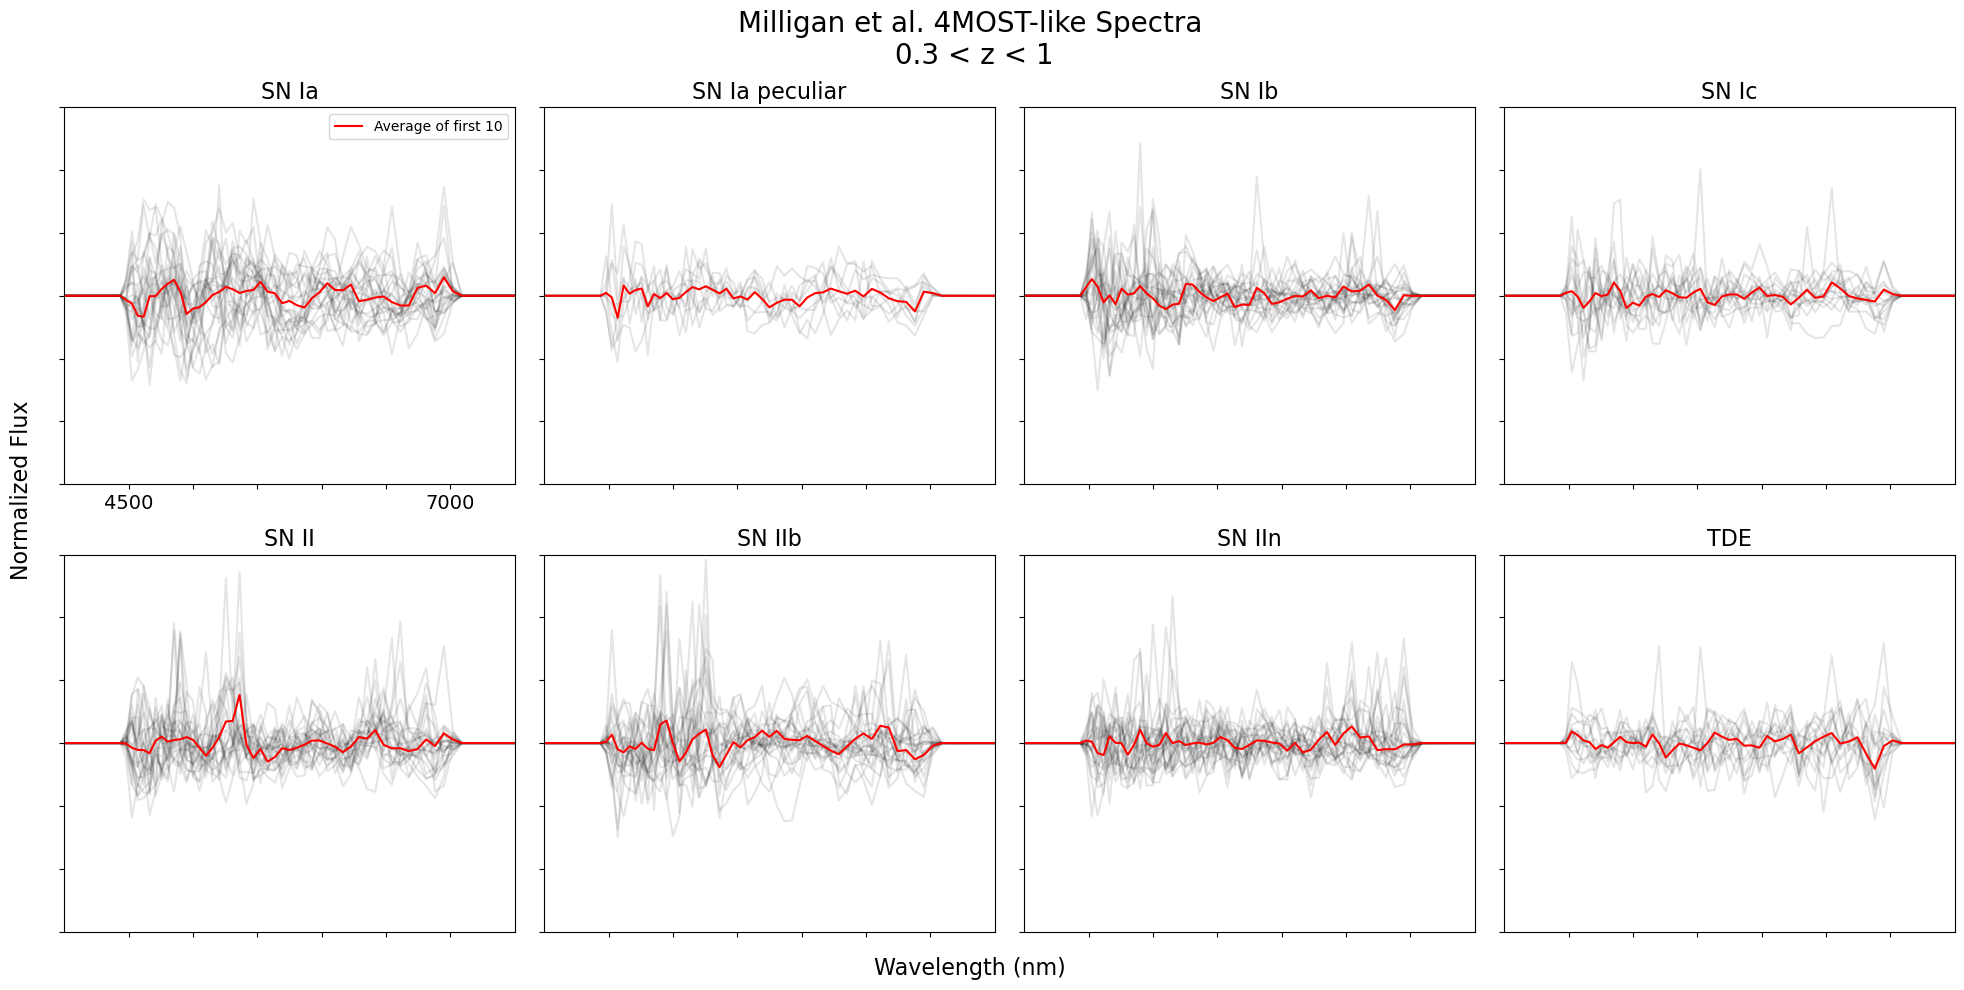

In [80]:
types = ['Ia', 'Iap', 'Ib',   'Ic', 'II', 'IIb', 'IIn', "TDE"]
types_titles = ['SN Ia', 'SN Ia peculiar', 'SN Ib',   'SN Ic', 'SN II', 'SN IIb', 'SN IIn', 'TDE']
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10)) # Adjust figsize as needed
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration
brighter_SN_index = df.host_mag < df.SN_mag + 1
large_z_index = (df.redshift > .3) & (df.redshift < 1)
large_z_df = df[large_z_index] #df[brighter_SN_index & small_z_index]


for j, sn_type in enumerate(types):
    ax = axes[j]
    temp_df = large_z_df[large_z_df.sn_type == sn_type]
    
    dat_size = len(temp_df)
    X_temp = np.zeros((num_wvl, ))

    for n, i in enumerate(temp_df.index.values):
        if n < 10:
            X_temp += X_all[i][0]
        if n < 25:
            ax.plot(wvl, X_all[i][0], alpha = 0.1, color = "k")

    if dat_size < 10:
        ax.plot(wvl, X_temp/dat_size , alpha = 1, color = "r", label="Average")
    else:
        ax.plot(wvl, X_temp/10 , alpha = 1, color = "r", label="Average of first 10")
    ax.set_title(f"{types_titles[j]}", fontsize = 16)
    ax.set_ylim(-3, 3)
    ax.set_xlim(4000,7500)
    ax.set_xticks([4500, 5000, 5500, 6000, 6500, 7000])
    ax.set_xticklabels(['', '', '', '', '', ''])
    ax.set_yticks([-3,-2,-1, 0, 1,2,3])
    ax.set_yticklabels(["", "", " ", " ", "", "", "" ])
    if j == 0:
        ax.legend()
        ax.set_xticks([4500, 5000, 5500, 6000, 6500, 7000])
        ax.set_xticklabels([4500, '', '', '', '', 7000], fontsize = 14)

fig.suptitle("Milligan et al. 4MOST-like Spectra\n 0.3 < z < 1", fontsize =20)

fig.supxlabel("Wavelength (nm)", fontsize = 16)
fig.supylabel("Normalized Flux\n", fontsize = 16)

plt.tight_layout(pad=1.1) # Adjust layout to prevent overlapping titles/labels
plt.savefig("large_z_.png")

In [58]:
large_z_df[large_z_df.sn_type != "SL"].redshift.max()

0.94492

In [7]:
temp_df.index.values

array([ 11,  23,  24,  33,  46,  59,  73,  81,  85, 115, 130, 177, 195,
       218, 241, 247, 248, 263, 305, 307, 309, 321, 323, 324, 326, 337,
       361, 368, 376, 406, 408, 417, 426, 449, 457])

In [8]:
 X_all[i][0].shape

(139,)

In [9]:
df

,filename,host,sn_type,redshift,SN_mag,host_mag,ABC_ID,Mill_ID,index
0,sbII_Smag21.589Gmag19.903z0.031531texp61.46.txt,sb,II,0.031531,21.589,19.903,NaN,NaN,9.0
1,s0Ib_Smag21.55Gmag19.776z0.045083texp51.84.txt,s0,Ib,0.045083,21.550,19.776,NaN,NaN,101.0
2,saIa_Smag17.882Gmag17.382z0.040948texp35.4.txt,sa,Ia,0.040948,17.882,17.382,NaN,NaN,142.0
3,scIa_Smag17.907Gmag16.31z0.039275texp62.732.txt,sc,Ia,0.039275,17.907,16.310,NaN,NaN,152.0
4,sbIa_Smag18.766Gmag20.636z0.048815texp51.788.txt,sb,Ia,0.048815,18.766,20.636,NaN,NaN,217.0
...,...,...,...,...,...,...,...,...,...
453,starb1TDESmag17.374Gmag20.307z0.024836texp18.6...,starb1,TDE,0.024836,17.374,20.307,NaN,NaN,304.0
454,sbIc_Smag19.191Gmag21.372z0.027308texp20.253.txt,sb,Ic,0.027308,19.191,21.372,NaN,NaN,312.0
455,s0Ia_Smag20.377Gmag21.793z0.013314texp62.18.txt,s0,Ia,0.013314,20.377,21.793,NaN,NaN,318.0
456,sbII_Smag23.666Gmag23.977z0.049583texp20.473.txt,sb,II,0.049583,23.666,23.977,NaN,NaN,336.0


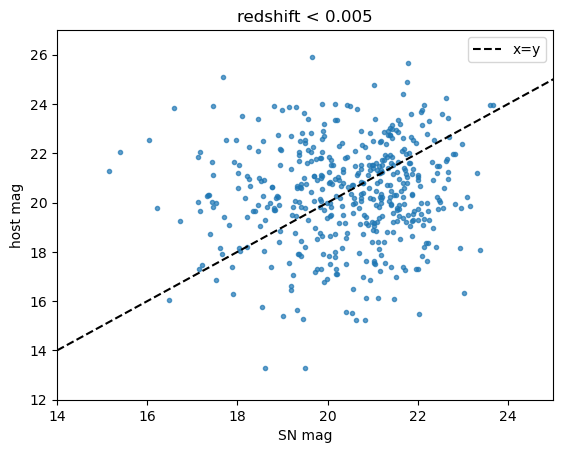

In [10]:
plt.scatter(df.SN_mag, df.host_mag, marker = ".", alpha = 0.7)
plt.plot([12,27], [12,27], color = "k", ls = "--", label = "x=y")
plt.ylim(12,27)
plt.xlim(14,25)
plt.xlabel("SN mag")
plt.ylabel("host mag")
plt.title("redshift < 0.005")
plt.legend()

Text(0.5, 1.0, 'host mag - SN mag \n redshift < 0.05')

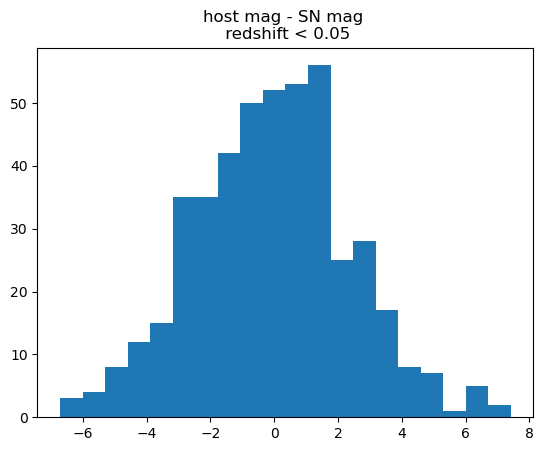

In [11]:
plt.hist(df.host_mag - df.SN_mag, bins= 20)
plt.title("host mag - SN mag \n redshift < 0.05")

(array([1389., 2572., 2704., 2524., 1698.,  991.,  427.,  158.,  109.,
          98.,   98.,   99.,   94.,   75.,   80.,  103.,   79.,   42.,
          70.,   33.]),
 array([0.011448 , 0.0858906, 0.1603332, 0.2347758, 0.3092184, 0.383661 ,
        0.4581036, 0.5325462, 0.6069888, 0.6814314, 0.755874 , 0.8303166,
        0.9047592, 0.9792018, 1.0536444, 1.128087 , 1.2025296, 1.2769722,
        1.3514148, 1.4258574, 1.5003   ]),
 <BarContainer object of 20 artists>)

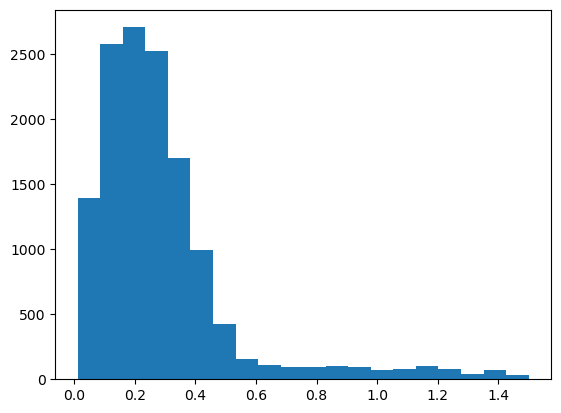

In [42]:
plt.hist(df.redshift, bins= 20)